In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
from matplotlib.patches import Ellipse
import torch

In [2]:
def plottelotte(center, sigma, target, title='VI: Gaussian Approximation vs Target', samples=None):
    w_1_range = [-4,4]
    w_2_range = w_1_range
    w1 = np.linspace(w_1_range[0],w_1_range[1],1000)
    w2 = np.linspace(w_2_range[0],w_2_range[1],1000)
    W1, W2 = np.meshgrid(w1, w2)
    Z_target = target(W1,W2)

    plt.figure(figsize=(10, 5))

    plt.imshow(Z_target, extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin='lower',aspect='auto', cmap= 'RdBu', alpha = 0.5, vmin=0, vmax=2)
    plt.colorbar(label='$\mathcal{L}(θ_1, θ_2)$')
    plt.xlabel('$θ_1$')
    plt.ylabel('$θ_2$')

    #PLOT THE APP POSTRIOR
    sigma_inv = np.linalg.inv(sigma)
    sigma_det = np.linalg.det(sigma)
    pos = np.dstack((W1, W2))
    diff = pos - center
    norm_const = 1.0 / ( (2*np.pi)**(2/2) * np.sqrt(sigma_det) )
    exponent = -0.5 * np.einsum('...i,ij,...j', diff, sigma_inv, diff)
    Z = norm_const * np.exp(exponent)
    plt.contourf(W1, W2, Z, cmap='Purples', alpha=0.6)
    plt.colorbar(label='Approximate Posterior $q(θ)$')
    c1, c2 = center[0], center[1]
    plt.scatter(c1, c2, c='red', label = f'$μ_q$ = ( {c1:.2f}, {c2:.2f})')

    #PLOT THE PRIOR:
    dim = 2
    sigma_inv = np.linalg.inv(np.eye(dim))
    sigma_det = np.linalg.det(sigma)
    pos = np.dstack((W1, W2))
    diff = pos
    norm_const = 1.0 / ( (2*np.pi)**(2/2) * np.sqrt(sigma_det) )
    exponent = -0.5 * np.einsum('...i,ij,...j', diff, sigma_inv, diff)
    Z = norm_const * np.exp(exponent)
    plt.contourf(W1, W2, Z, cmap='Oranges', alpha=0.2)
    plt.colorbar(label='Prior $p(θ) = \mathcal{N}(0,I)$')
    plt.scatter(0, 0, c='orange', label = '$μ_p$')

    
    plt.xlim(w_1_range[0], w_1_range[1])
    plt.ylim(w_2_range[0], w_1_range[1])
    plt.legend()
    plt.title(title)
    plt.show()

def toy(x, y):
    return (x*y - 1)**2

In [3]:
n_samples = 1000
n_iters = 500

def target_log_prob(w):
    return -(w[:, 0] * w[:, 1] - 1)**2

def Loss(w1,w2):
    return  (w1*w2-1)**2

mu = torch.tensor([2.0, 2.0], requires_grad=True)
L_unconstrained = torch.tensor([0.0, 0.0, 0.0], requires_grad=True)

optimizer = torch.optim.Adam([mu, L_unconstrained], lr=0.01)
n_samples = 1000

def build_L(L_unconstrained):
    a_raw, b, c_raw = L_unconstrained[0], L_unconstrained[1], L_unconstrained[2]
    a = torch.nn.functional.softplus(a_raw) + 1e-5
    c = torch.nn.functional.softplus(c_raw) + 1e-5
    L = torch.stack([
        torch.stack([a, torch.tensor(0.0)]),
        torch.stack([b, c])
    ])
    return L

ELBO_history = []
Likelihood_history = []
KL_history = []
dim = 2

for i in range(n_iters):
    optimizer.zero_grad()

    L = build_L(L_unconstrained)
    eps = torch.randn(n_samples, 2)
    w_samples = mu + eps @ L.T

    d = 2
    diff = (w_samples - mu)
    y = torch.linalg.solve_triangular(L, diff.T, upper=False)
    mahal = torch.sum(y**2, dim=0)

    log_det = 2.0 * torch.sum(torch.log(torch.diag(L)))
    log_q = -0.5 * (d * np.log(2*np.pi) + log_det + mahal)

    log_p = -0.5 * (w_samples**2).sum(dim=1) - 0.5 * d * np.log(2*np.pi)

    KL = torch.mean(log_q - log_p)
    KL_history.append(KL.detach().item())

    exp = target_log_prob(w_samples)
    exp = torch.mean(exp)
    Likelihood_history.append(-(exp.detach().item()))

    ELBO = exp - KL
    objective = -ELBO
    
    ELBO_history.append(objective.detach().item())

    objective.backward()
    optimizer.step()

    if i % 100 == 0:
        L_step = build_L(L_unconstrained).detach().numpy()
        Sigma_step = L_step @ L_step.T
        print(f"Iter {i}: Loss {objective.item():.4f}, mu {mu.detach().numpy()}, Sigma \n {Sigma_step} ")

final_mu = mu.detach().numpy()
L_final = build_L(L_unconstrained).detach().numpy()
Sigma_final = L_final @ L_final.T

print("\nFinal mu:", final_mu)
print("Final Sigma:\n", Sigma_final)

Iter 0: Loss 17.7158, mu [1.99 1.99], Sigma 
 [[ 0.47357756 -0.0068817 ]
 [-0.0068817   0.47367755]] 
Iter 100: Loss 3.2512, mu [1.2923148 1.3049526], Sigma 
 [[ 0.372768  -0.2910125]
 [-0.2910125  0.43626  ]] 
Iter 200: Loss 2.1506, mu [1.021866  1.0343026], Sigma 
 [[ 0.34842145 -0.19911526]
 [-0.19911526  0.3437991 ]] 
Iter 300: Loss 1.8255, mu [0.8607099 0.8614788], Sigma 
 [[ 0.3349626  -0.10566592]
 [-0.10566592  0.3220658 ]] 
Iter 400: Loss 1.6219, mu [0.7302101 0.7275882], Sigma 
 [[ 0.35399604 -0.03644415]
 [-0.03644415  0.34029147]] 

Final mu: [0.61344856 0.609462  ]
Final Sigma:
 [[0.39123037 0.02303666]
 [0.02303666 0.3803151 ]]


## Plot Convergence

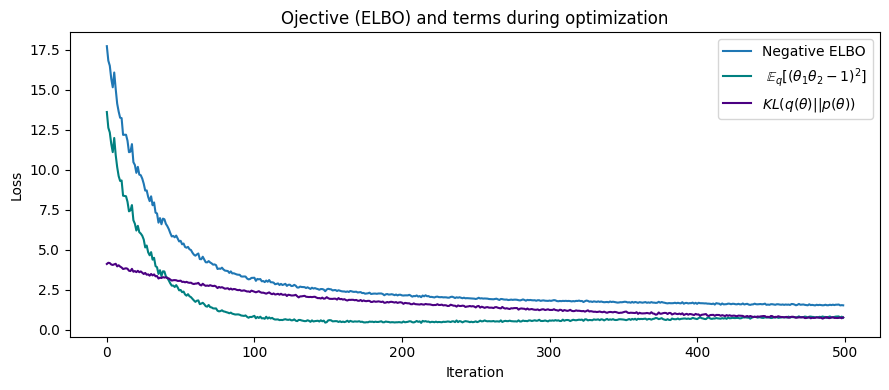

In [4]:
plt.figure(figsize=(9, 4))
plt.title('Ojective (ELBO) and terms during optimization')
plt.plot(np.array(ELBO_history),label = 'Negative ELBO')
plt.plot(np.array(Likelihood_history), label=" $\mathbb{E}_q[(θ_1 θ_2-1)^2]$", c = 'teal')
plt.plot(np.array(KL_history), label="$KL(q(θ)||p(θ))$", c = 'indigo')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

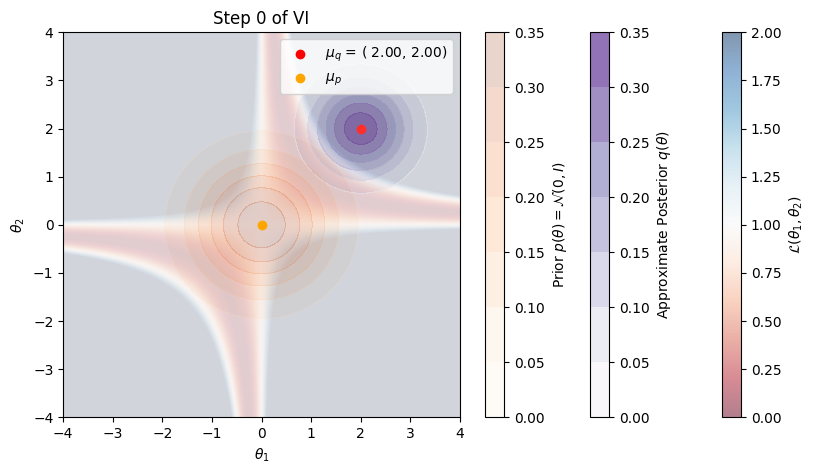

In [5]:
plottelotte(np.array([2,2]), np.array([[ 0.47357756 ,-0.0068817 ],
 [-0.0068817  , 0.47367755]] ),toy, 'Step 0 of VI')

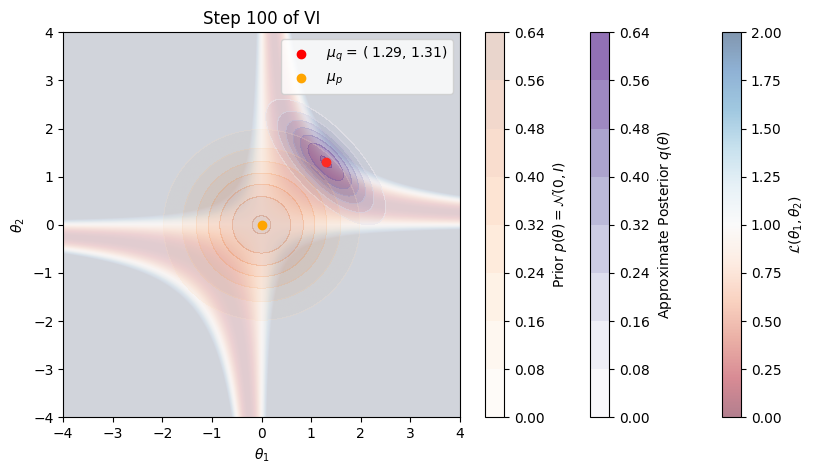

In [6]:
plottelotte(np.array([1.2932962, 1.3069417]), np.array([[ 0.3724782 , -0.29005346],
 [-0.29005346 , 0.43513843]] ),toy, 'Step 100 of VI')

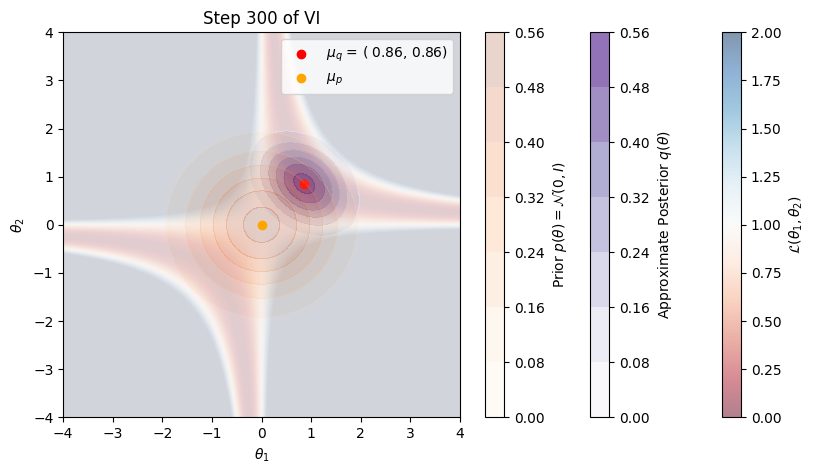

In [7]:
plottelotte(np.array([0.85907066, 0.8575555 ]), np.array([[ 0.33349845 ,-0.10512329],
 [-0.10512329  ,0.3218489 ]] ),toy, 'Step 300 of VI')


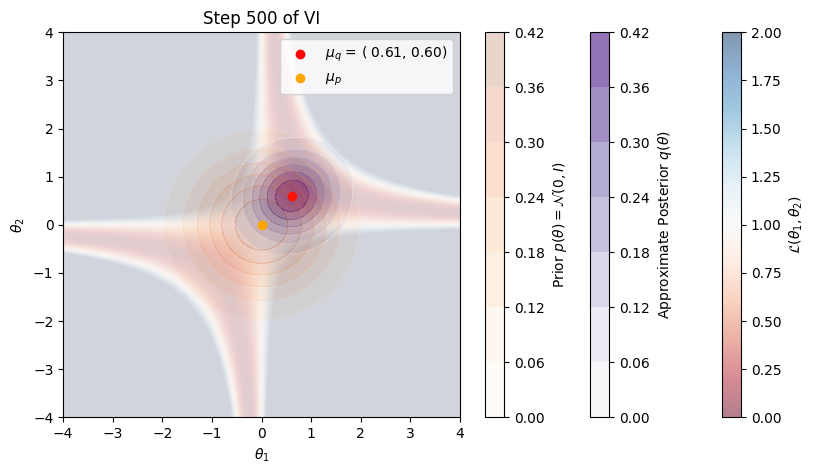

In [8]:
plottelotte(np.array([0.6139067, 0.6049941]), np.array([[0.39127183, 0.02938918],
 [0.02938918 ,0.3816582 ]] ),toy, 'Step 500 of VI')
